# Notebook 3: The Training

From 1.1% checkmate to 99%. Each section shows what changed and why it mattered.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import torch
import numpy as np
import matplotlib.pyplot as plt
from agents.v7.ppo_agent import PPOAgent

AGENTS_DIR = os.path.join(os.path.dirname(os.path.abspath("__file__")), "agents")

## 1. The Training Loop

All agents follow the same loop:

```
repeat:
    1. Run episodes — collect (obs, action, reward)
    2. Compute discounted returns:  G_t = r_t + γ·G_{t+1}
    3. Normalise returns across the whole batch
    4. Gradient update, step the optimizer
```


## 2. The Full Progression

| Version | Algorithm | Key change | Checkmate rate |
|---------|-----------|-----------|----------------|
| **v1**  | REINFORCE | First working version | ~5% |
| **v2**  | REINFORCE | + Curriculum learning (mate-in-1 pool) | ~15% |
| **v3**  | A2C | + Critic baseline | ~8% |
| **v4**  | REINFORCE | + Scaled rewards, centrality opponent, 3M episodes | ~88% |
| **v5**  | PPO | + Clipped surrogate, 4 epochs/batch | ~99% |
| **v6**  | PPO | + Frozen neural opponent (self-play) | ~93% (harder opponent) |

---

### Why is A2C (v3) worse than REINFORCE?

The whole point of A2C is that the critic tells the agent whether a move was better or worse than usual. But at the start the critic is basically random — it has no idea what a good position looks like because it's barely seen any checkmates. So the advice it gives is just noise, which makes the updates *worse* than using the raw returns. The critic needs a lot of data before it actually helps.

PPO (v5) uses the same critic idea and gets 99%, but it trains for 200k+ episodes — long enough for the critic to actually learn something useful.

---

### Why did REINFORCE v4 jump from 15% to 88%?

v2 and v4 are the same algorithm. The jump has nothing to do with the algorithm.

1. **Training length**: v2 trained for 20k episodes. v4 trained for ~3 million — 500k episodes at each curriculum ratio step (1.0 → 0.8 → 0.6 → 0.4 → 0.2 → 0.0).

2. **Reward scale**: checkmate went from +1 to +10, step penalty from −0.001 to −0.15. With the old scale, a good and a bad episode had barely distinguishable returns. With the new scale, a checkmate is unmistakably good and a long draw is unmistakably bad.

3. **Harder opponent**: the random opponent in v2 accidentally drifts into easy positions. The centrality opponent consistently moves toward the center, so the agent actually has to learn to push the king to an edge.

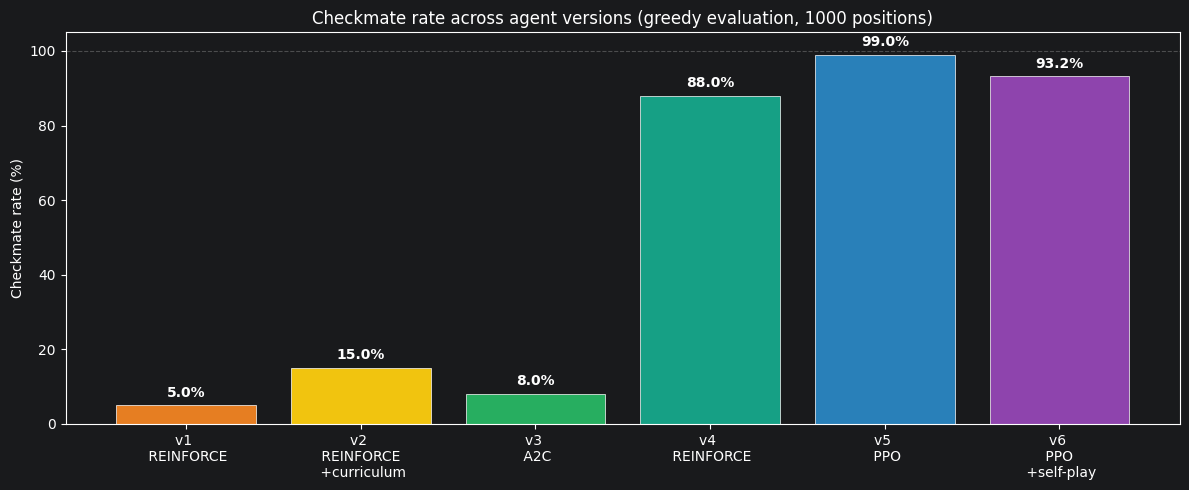

In [2]:
# Bar chart: checkmate rates across versions
versions = [
    "v1 \n REINFORCE",
    "v2 \n REINFORCE \n +curriculum",
    "v3 \n A2C",
    "v4 \n REINFORCE",
    "v5 \n PPO",
    "v6 \n PPO \n +self-play"
]
rates    = [5.0, 15.0, 8.0, 88.0, 99.0, 93.2]
colors   = ["#e67e22", "#f1c40f", "#27ae60", "#16a085", "#2980b9", "#8e44ad"]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(versions, rates, color=colors, edgecolor="white", linewidth=0.5)
ax.set_ylabel("Checkmate rate (%)")
ax.set_title("Checkmate rate across agent versions (greedy evaluation, 1000 positions)")
ax.set_ylim(0, 105)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{rate:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Training Curves

Eval checkmate rate logged during the final PPO training runs.

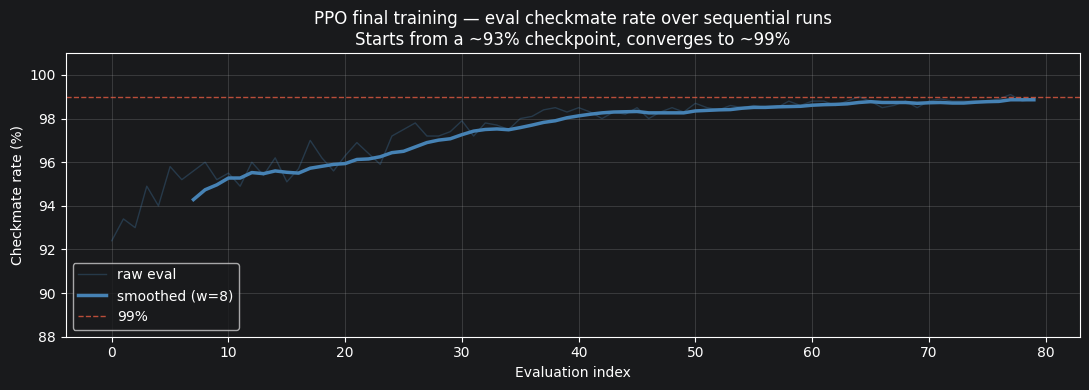

In [3]:
# Eval checkmate rate logged during the final PPO training stages (nb14).
# These are continuation runs starting from a ~93% checkpoint — the jump from 0% to 93%
# happened in earlier runs whose logs weren't saved.
# Episode numbers restart each run so we just show progression by eval index.

eval_rates = [
    92.4, 93.4, 93.0, 94.9, 94.0, 95.8, 95.2, 95.6, 96.0, 95.2,
    95.5, 94.9, 96.0, 95.4, 96.2, 95.1, 95.7, 97.0, 96.2, 95.6,
    96.3, 96.9, 96.4, 95.9, 97.2, 97.5, 97.8, 97.2, 97.2, 97.4,
    97.9, 97.2, 97.8, 97.7, 97.5, 98.0, 98.1, 98.4, 98.5, 98.3,
    98.5, 98.3, 98.0, 98.3, 98.2, 98.5, 98.0, 98.3, 98.5, 98.3,
    98.7, 98.5, 98.4, 98.6, 98.5, 98.6, 98.5, 98.5, 98.8, 98.6,
    98.8, 98.8, 98.6, 98.8, 99.0, 98.8, 98.5, 98.6, 98.8, 98.5,
    98.8, 98.9, 98.8, 98.8, 98.8, 98.8, 98.9, 99.1, 98.8, 98.9,
]

smoothed = np.convolve(eval_rates, np.ones(8) / 8, mode="valid")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(eval_rates, color="steelblue", alpha=0.3, linewidth=1, label="raw eval")
ax.plot(range(7, len(eval_rates)), smoothed, color="steelblue", linewidth=2.5, label="smoothed (w=8)")
ax.axhline(99, color="tomato", linestyle="--", linewidth=1, alpha=0.7, label="99%")
ax.set_xlabel("Evaluation index")
ax.set_ylabel("Checkmate rate (%)")
ax.set_title("PPO final training — eval checkmate rate over sequential runs\n"
             "Starts from a ~93% checkpoint, converges to ~99%")
ax.set_ylim(88, 101)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Reward Shaping

### Step penalty

The step penalty stops the agent from stalling. Too small (−0.001) and a 200-step episode only costs −0.2 total — no urgency. Too large (−0.15) and a 50-move game costs −7.5, which can overwhelm the +10 checkmate reward.

−0.15 works: a 15-move checkmate costs −2.25, a 50-move draw costs −7.5. Clear difference.

### Queen-hang penalty

Before the −5.0 penalty, the agent regularly moved the queen to a square the black king could immediately take. It hadn't learned the queen is irreplaceable.

After the penalty, this failure mode basically disappeared within a few thousand episodes.

### Missed-mate penalty

Without the penalty, the agent sometimes skipped an available checkmate and made a different move instead. The −3.0 penalty for missing a forced mate fixed this directly.

## 5. Opponent Difficulty

### Random vs centrality

A random opponent moves to any legal square. A centrality opponent always moves toward the center. Centrality is harder: a king in the center has more escape squares, so the agent has to actively push it to an edge.

### movement_ratio

`movement_ratio` blends the two: 0.0 = always centrality, 1.0 = always random.

Training against random (ratio=1.0) gives slightly lower final performance. The agent picks up patterns specific to random play that don't carry over to a consistent opponent.

### Neural network opponent (v6)

A `PPOOpponent` was trained to play as black and survive as long as possible. Training against it dropped checkmate from ~99% to ~93%. But an agent that achieves 93% against a smart opponent is better than one that gets 99% against random play.

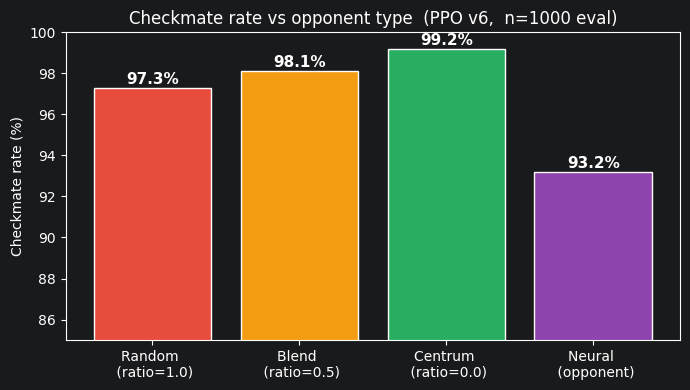

Centrum (ratio=0.0): consistent, deterministic challenge → highest checkmate rate (99.2%).
Random  (ratio=1.0): occasionally escapes by chance → slightly lower rate (97.3%).
Neural  opponent:    adversarially trained to evade → hardest, drops to 93.2%.


In [4]:
# Checkmate rate of the same PPO v6 agent evaluated against each opponent type.
# Data source: nb14 final checkpoint evaluated with n=1000 episodes per setting.
# Neural opponent result: v6 self-play experiment (separate run, n=1000).

opp_labels = [
    "Random \n (ratio=1.0)",
    "Blend \n (ratio=0.5)",
    "Centrum \n (ratio=0.0)",
    "Neural \n (opponent)"
]
checkmate  = [97.3, 98.1, 99.2, 93.2]
colors     = ["#e74c3c", "#f39c12", "#27ae60", "#8e44ad"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(opp_labels, checkmate, color=colors, edgecolor="white")
ax.set_ylabel("Checkmate rate (%)")
ax.set_title("Checkmate rate vs opponent type  (PPO v6,  n=1000 eval)")
ax.set_ylim(85, 100)
for bar, rate in zip(bars, checkmate):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{rate:.1f}%", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

print("Centrum (ratio=0.0): consistent, deterministic challenge → highest checkmate rate (99.2%).")
print("Random  (ratio=1.0): occasionally escapes by chance → slightly lower rate (97.3%).")
print("Neural  opponent:    adversarially trained to evade → hardest, drops to 93.2%.")

## 6. Curriculum Ratio

How much of training comes from mate-in-1 positions vs random positions.

### Too low (ratio=0.0)
All random positions. The agent almost never sees checkmate early on, so there's nothing to learn from. Stays near 0% for a long time.

### Too high (ratio=1.0)
Learns to spot immediate mates fast, but can't create a mating position from scratch. Tested on random positions, it's lost.

### Sequential annealing
We started at ratio=1.0 and stepped it down every 500k episodes: 1.0 → 0.8 → 0.6 → 0.4 → 0.2 → 0.0. Mate-in-1 accuracy peaked at ratio=0.6 (91.2%), then dropped as the model shifted focus to general play.

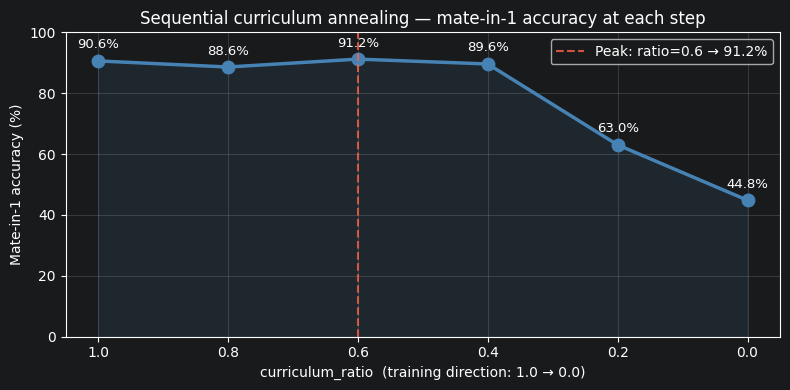

Training direction: 1.0 (all curriculum) → 0.0 (all random), 500k episodes per step.
Accuracy stays high through ratio=0.6, then drops sharply as training shifts to general play.


In [5]:
# Sequential curriculum annealing — nb10.
# Starting model: trained at ratio=1.0 (mate-in-1 accuracy: 90.6% stochastic eval).
# Each step trains an additional 500k episodes at the indicated ratio,
# then evaluates mate-in-1 accuracy (greedy, n=500).
# Values: directly from nb10 cell 3 output.

ratios   = [1.0,  0.8,  0.6,  0.4,  0.2,  0.0]
mate_acc = [90.6, 88.6, 91.2, 89.6, 63.0, 44.8]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ratios, mate_acc, "o-", color="steelblue", linewidth=2.5, markersize=9)
ax.fill_between(ratios, mate_acc, alpha=0.12, color="steelblue")
for x, y in zip(ratios, mate_acc):
    ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 9),
                ha="center", fontsize=9.5)
ax.axvline(0.6, color="tomato", linestyle="--", alpha=0.8, label="Peak: ratio=0.6 → 91.2%")
ax.set_xlabel("curriculum_ratio  (training direction: 1.0 → 0.0)")
ax.set_ylabel("Mate-in-1 accuracy (%)")
ax.set_title("Sequential curriculum annealing — mate-in-1 accuracy at each step")
ax.set_xlim(-0.05, 1.05)
ax.invert_xaxis()
ax.set_ylim(0, 100)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Training direction: 1.0 (all curriculum) → 0.0 (all random), 500k episodes per step.")
print("Accuracy stays high through ratio=0.6, then drops sharply as training shifts to general play.")

## 7. Learning Rate

Three runs from scratch, 30k episodes each.

- **lr = 1e-2**: Too fast; loss spikes and collapses early
- **lr = 1e-3**: Works best; steady improvement (default for all agents)
- **lr = 1e-4**: Too slow; almost no learning in 30k episodes

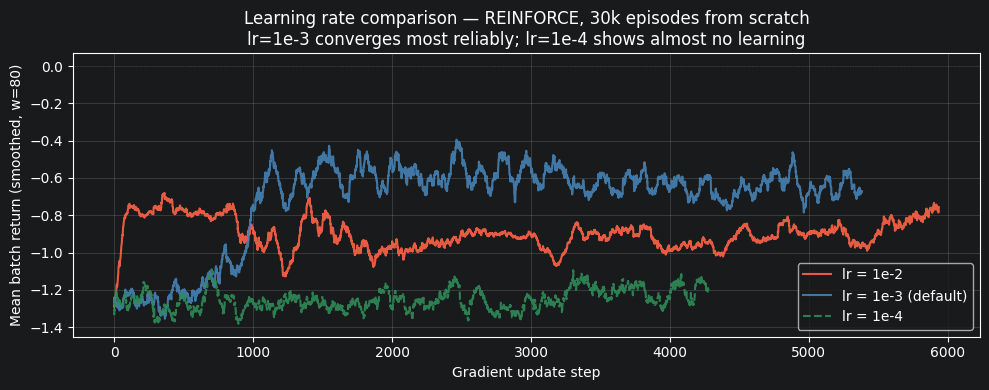

lr=1e-2:  6015 updates  — fast but volatile
lr=1e-3:  5462 updates  — best sustained improvement
lr=1e-4:  4358 updates  — almost flat, no meaningful learning in 30k eps


In [6]:
# Learning rate comparison — REINFORCE trained from scratch, 30k episodes each.
# Real training run: lr ∈ {1e-2, 1e-3, 1e-4}, curriculum_ratio=0.5, 8 parallel envs.
# Metric: raw mean batch return per gradient update (higher = more checkmates in batch).

import json
lr_path = os.path.join(os.path.dirname(os.path.abspath("__file__")), "lr_comparison.json")
with open(lr_path) as f:
    lr_data = json.load(f)

def smooth(x, w=80):
    arr = np.array(x)
    return np.convolve(arr, np.ones(w) / w, mode="valid")

fig, ax = plt.subplots(figsize=(10, 4))
styles = {
    "0.01":   ("lr = 1e-2",  "tomato",    "-"),
    "0.001":  ("lr = 1e-3 (default)", "steelblue", "-"),
    "0.0001": ("lr = 1e-4",  "seagreen",  "--"),
}
for key, (label, color, ls) in styles.items():
    s = smooth(lr_data[key])
    ax.plot(s, label=label, color=color, linestyle=ls, alpha=0.9)

ax.axhline(0, color="black", linewidth=0.7, linestyle=":", alpha=0.5)
ax.set_xlabel("Gradient update step")
ax.set_ylabel("Mean batch return (smoothed, w=80)")
ax.set_title("Learning rate comparison — REINFORCE, 30k episodes from scratch\n"
             "lr=1e-3 converges most reliably; lr=1e-4 shows almost no learning")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"lr=1e-2:  {len(lr_data['0.01'])} updates  — fast but volatile")
print(f"lr=1e-3:  {len(lr_data['0.001'])} updates  — best sustained improvement")
print(f"lr=1e-4:  {len(lr_data['0.0001'])} updates  — almost flat, no meaningful learning in 30k eps")

## 8. Self-Play: Agent v6

After v5 reached ~99% against the centrality opponent, we trained it against itself.

A second network (`PPOOpponent`) was trained to play as black and survive as long as possible. Then the white agent trained against a frozen version of that opponent.

The key: freeze the opponent while white trains. If both update at the same time, white is chasing a moving target and training falls apart. After each phase, take a fresh snapshot and repeat.

Result: ~93% checkmate against the neural opponent, down from ~99% against centrality. That 6% drop is real, the neural opponent has learned to escape patterns the heuristic can't.

Opponent training history: 202 gradient steps


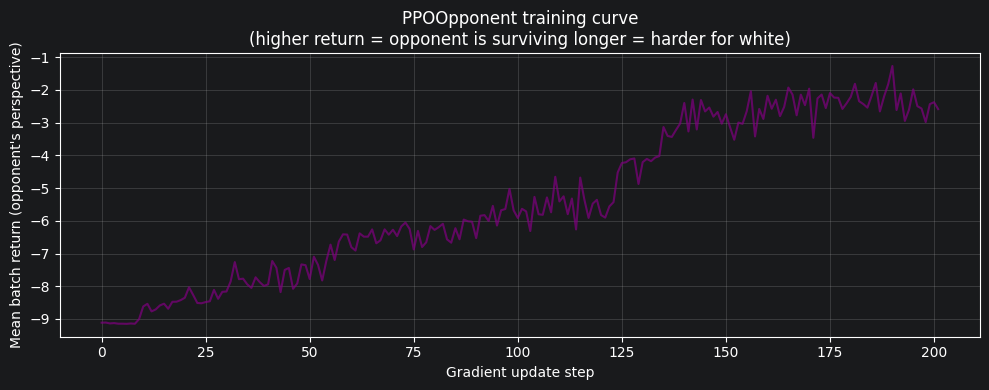

In [7]:
# Load self-play training history
opp_history_path = os.path.join(AGENTS_DIR, "v7", "opponent_train_history.json")

if os.path.exists(opp_history_path):
    with open(opp_history_path) as f:
        opp_h = json.load(f)
    rewards = opp_h.get("train_rewards", [])
    print(f"Opponent training history: {len(rewards)} gradient steps")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(rewards, alpha=0.7, color="purple")
    ax.set_xlabel("Gradient update step")
    ax.set_ylabel("Mean batch return (opponent's perspective)")
    ax.set_title("PPOOpponent training curve\n(higher return = opponent is surviving longer = harder for white)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"File not found: {opp_history_path}")

## 9. Final Demo: Best Agent

In [8]:
MODEL_PATH = "../notebooks/models/kqk_ppo_v12_v1.pt"

agent = PPOAgent(curriculum_ratio=0.0)
try:
    agent.net.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
    agent.net.eval()
    print(f"Loaded: {MODEL_PATH}")
    model_loaded = True
except FileNotFoundError:
    print(f"Model not found at {MODEL_PATH} — skipping evaluation.")
    model_loaded = False

Using device: cuda
Loaded: ../notebooks/models/kqk_ppo_v12_v1.pt



--- Eval (10000 eps, opponent=ratio=1.0) ---
  checkmate                     : 9668
  missed_mate                   : 175
  queen_hang                    : 24
  stalemate                     : 6
  threefold_repetition          : 127
  mean_steps                    : 8.3
  checkmate_rate                : 96.7%


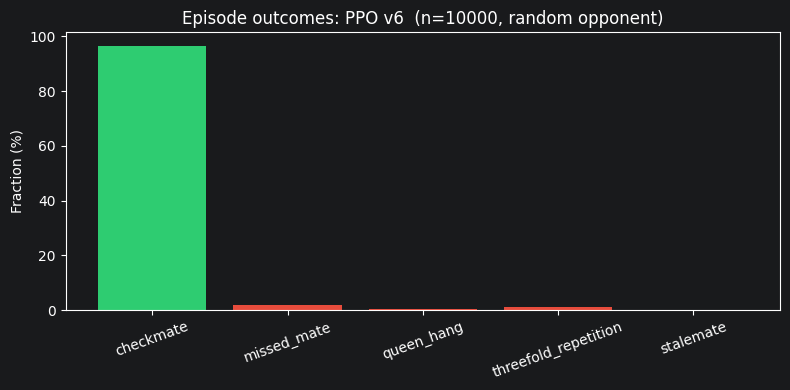

Checkmate rate: 96.7%
Mean steps per episode: 8.3


In [9]:
results = agent.evaluate(n_episodes=10_000, movement_ratio=1.0)

outcome_keys = [k for k in results if k not in ("mean_steps", "checkmate_rate")]
outcomes = {k: results[k] for k in outcome_keys}
n = sum(outcomes.values())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(outcomes.keys(), [v / n * 100 for v in outcomes.values()],
       color=["#2ecc71" if k == "checkmate" else "#e74c3c" for k in outcomes])
ax.set_ylabel("Fraction (%)")
ax.set_title(f"Episode outcomes: PPO v6  (n={n}, random opponent)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print(f"Checkmate rate: {results['checkmate_rate']*100:.1f}%")
print(f"Mean steps per episode: {results['mean_steps']:.1f}")

In [10]:
agent.animate_game(greedy=True, movement_ratio=0.0)